# Figure 3: Decision variable prediction

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd "/app/"

/app


/usr/local/lib/python3.9/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
%run env_aws.py
%run run.py connect

2026-01-20 16:18:50,179::INFO::settings.py::Setting loglevel to INFO
2026-01-20 16:18:50,180::INFO::settings.py::Setting stores to {}
2026-01-20 16:18:50,180::INFO::settings.py::Setting database.misc.schema_prefix to 
2026-01-20 16:18:50,181::INFO::settings.py::Setting database.misc.create_tables to True
2026-01-20 16:18:50,182::INFO::settings.py::Setting enable_python_native_blobs to True
2026-01-20 16:18:50,183::INFO::settings.py::Setting database.host to vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com
2026-01-20 16:18:50,183::INFO::settings.py::Setting database.user to celia
2026-01-20 16:18:50,184::INFO::settings.py::Setting database.password to celia_mathislab


Connecting celia@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


2026-01-20 16:18:50,483::INFO::connection.py::Connected celia@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306
2026-01-20 16:18:50,584::INFO::table.py::could not log event in table ~log
2026-01-20 16:18:51,014::INFO::table.py::could not log event in table ~log
2026-01-20 16:18:51,014::INFO::table.py::could not log event in table ~log
2026-01-20 16:18:51,697::INFO::table.py::could not log event in table ~log
2026-01-20 16:18:51,697::INFO::table.py::could not log event in table ~log
2026-01-20 16:18:51,845::INFO::table.py::could not log event in table ~log
2026-01-20 16:18:51,845::INFO::table.py::could not log event in table ~log
2026-01-20 16:18:52,231::INFO::table.py::could not log event in table ~log
2026-01-20 16:18:52,231::INFO::table.py::could not log event in table ~log
2026-01-20 16:18:52,562::INFO::table.py::could not log event in table ~log
2026-01-20 16:18:52,562::INFO::table.py::could not log event in table ~log


In [ ]:
from vr4mice.schema.base_analysis import DataFrame
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from vr4mice.analysis import plotting
from vr4mice.schema import base_analysis
from vr4mice.analysis.analysis import style
from vr4mice.schema.interpolated_trajectories import InterpolatedTrials
from vr4mice.schema.session_metrics import TrialMetrics
from vr4mice.analysis import utils
from vr4mice.analysis import regression

from statsmodels.stats.anova import AnovaRM
from scipy.stats import ttest_ind
import scipy.stats as stats

style()

save_fig_path = "notebooks/Paper_figures/Figure_output/"

2026-01-20 16:18:52,765::INFO::table.py::could not log event in table ~log
2026-01-20 16:18:52,765::INFO::table.py::could not log event in table ~log
2026-01-20 16:18:52,923::INFO::table.py::could not log event in table ~log
2026-01-20 16:18:52,923::INFO::table.py::could not log event in table ~log


In [5]:
trial_df = (TrialMetrics() * vr4mice.Groups() * vr4mice.Labels() * (vr4mice.Dataset() & 'session_label = "ar_discrim_occluders"')).fetch(as_dict=True)
trial_df =  pd.concat([pd.DataFrame(x) for x in trial_df])
# Exclude sessions that were not in the list
trial_df, reward_table = utils.apply_inclusion_criteria(trial_df, 
                                                        task_type="dual_occluder",
                                                        return_excluded=False)
# Create list of included datasets
mouse_list = trial_df.dataset.unique()
trial_df["mouse_name"] = trial_df.dataset.str.split("_").str [0]

In [6]:
trial_df.dataset.nunique(), trial_df.mouse_name.nunique()

(43, 10)

In [7]:
# This takes a while to fetch because we need to fetch data for all trials (4 min 20 secs) 
dataset_list = []
for d in mouse_list:
    print(d)
    try:
        if len(InterpolatedTrials() & f'dataset = "{d}"') > 0:
            dataset_list.append(pd.DataFrame((InterpolatedTrials() & f'dataset = "{d}"').fetch(as_dict=True)[0]))
        else:
            print("dataset missing")
    except Exception as err:
        print(err, " dataset missing")
interpolated_df = pd.concat(dataset_list)
interpolated_df["mouse_name"] = interpolated_df.dataset.str.split("_").str [0]

Pheasant_2024-08-21_1
Pheasant_2024-08-20_1
Pheasant_2024-08-19_1
Pheasant_2024-08-16_1
Pheasant_2024-08-15_2
Oribi_2024-08-22_1
Oribi_2024-08-21_1
Oribi_2024-08-20_1
Oribi_2024-08-19_1
Oribi_2024-08-16_1
Nightingale_2024-08-14_1
Nightingale_2024-08-13_1
Nightingale_2024-08-12_1
Nightingale_2024-08-11_1
Nightingale_2024-08-10_1
Lemming_2024-08-13_1
Lemming_2024-08-12_1
Lemming_2024-08-11_1
Lemming_2024-08-10_1
Kiwi_2024-08-14_1
Kiwi_2024-08-13_1
Kiwi_2024-08-12_2
Kiwi_2024-08-11_4
Kiwi_2024-08-10_2
Jacana_2024-08-19_1
Jacana_2024-08-16_1
Jacana_2024-08-15_1
Jacana_2024-08-14_1
Jacana_2024-08-13_1
J731_2024-12-05_1
J729_2024-12-10_1
J729_2024-12-04_1
J729_2024-12-03_1
J729_2024-12-02_1
J729_2024-12-01_1
J729_2024-11-30_1
31728_2025-03-21_1
31728_2025-03-20_1
31728_2025-03-07_1
31726_2025-03-21_1
31726_2025-03-20_1
31726_2025-03-19_1
31726_2025-03-18_1


In [8]:
box_df = base_analysis.BoxDataFrame().get_data(key={"dataset": "Pheasant_2024-08-15_2"})

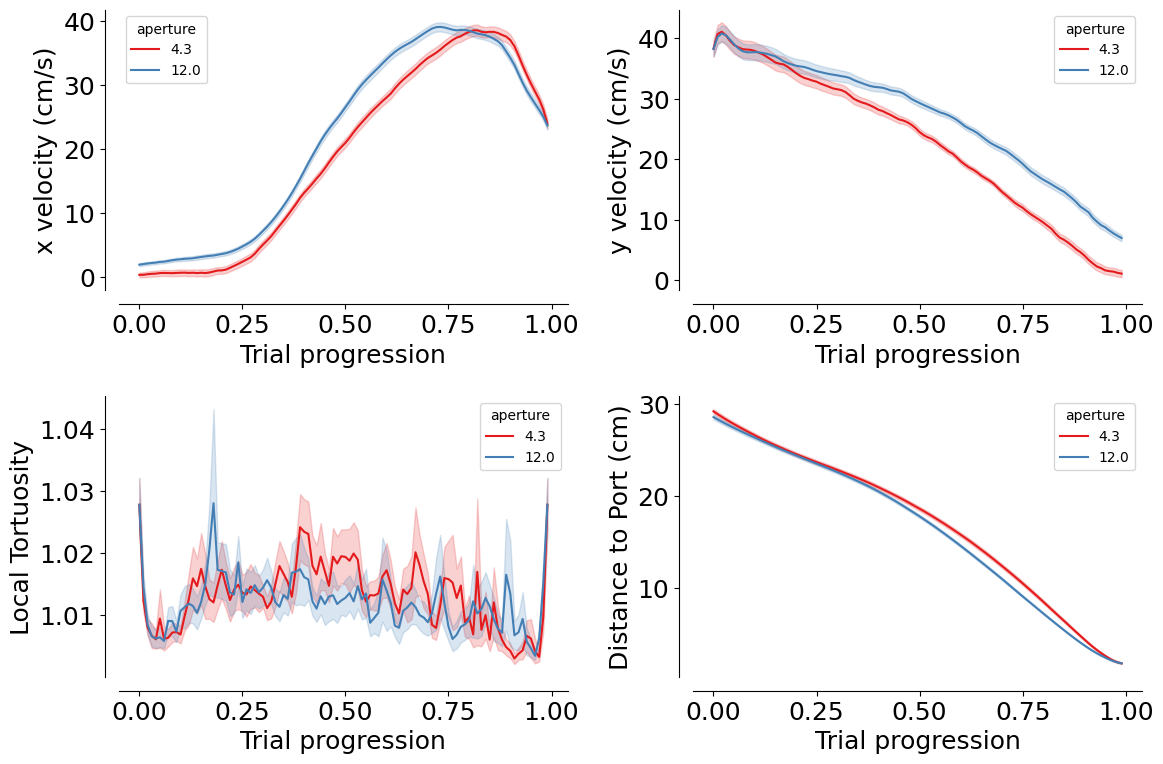

In [9]:
mean_mouse = interpolated_df.groupby(
    ["dataset", "aperture", "trial_length"], as_index=False
).mean(numeric_only=True)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax = ax.flatten()

for (i, label), label_str in zip(enumerate(
    ["velocity_x_fliped", "velocity_y", "local_tortuosity", "distance_to_choice"]
), ["x velocity (cm/s)", "y velocity (cm/s)", "Local Tortuosity", "Distance to Port (cm)"]):
    sns.lineplot(
        data=mean_mouse,
        x="trial_length",
        y=label,
        palette=(
            plotting.colors_aperture[:2]
            if len(mean_mouse.aperture.unique()) == 2
            else "viridis"
        ),
        hue="aperture",
        errorbar="se",
        ax=ax[i],
    )
    ax[i].set_ylabel(label_str)
    ax[i].set_xlabel("Trial progression")
    sns.despine(ax=ax[i], offset=10)
    
plt.tight_layout(pad=2)
plt.savefig(save_fig_path + "figure3_velocity_tortuosity_distance.svg", bbox_inches="tight", transparent=True)

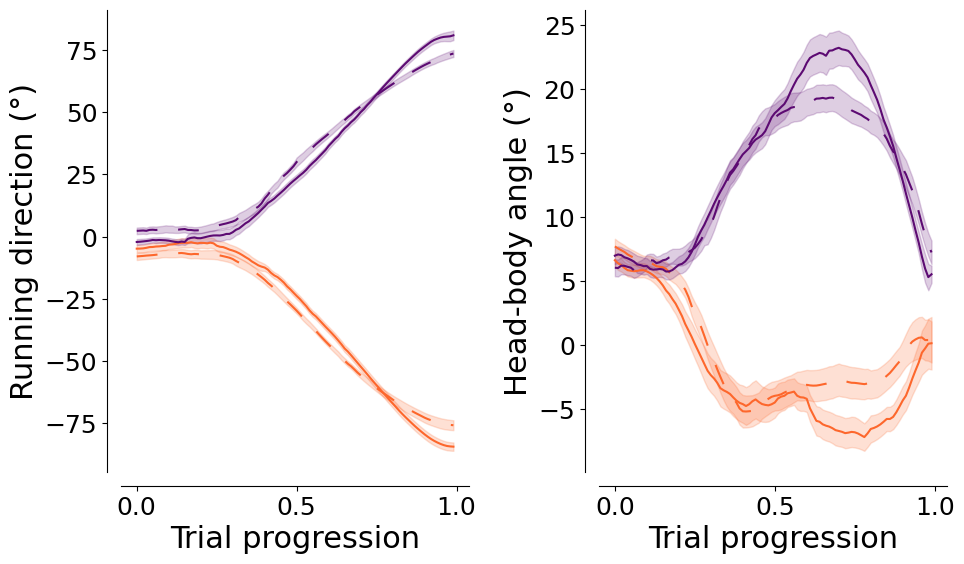

In [10]:
mean_mouse = interpolated_df.groupby(
    ["dataset", "aperture", "trial_left_choice", "trial_length"], as_index=False
).mean(numeric_only=True)

fig, ax = plt.subplots(1, 2, figsize=(10, 6))
ax = ax.flatten()

dash_styles = {
    mean_mouse.aperture.unique()[0]: "",         # Solid
    mean_mouse.aperture.unique()[1]: (10, 10)      # Dashed
}

for (i, label), label_str in zip(enumerate(["heading_dir", "head_angle"]), 
                                 ["Running direction (°)", "Head-body angle (°)"]):
    sns.lineplot(
        data=mean_mouse,
        x="trial_length",
        y=label,
        palette=plotting.colors_choice[::-1]
        if len(mean_mouse.aperture.unique()) == 2
        else "viridis",
        hue="trial_left_choice"
        if len(mean_mouse.aperture.unique()) == 2
        else "aperture",
        style=(
            "aperture"
            if len(mean_mouse.aperture.unique()) == 2
            else "trial_left_choice"
        ),
        errorbar="se",
        dashes=dash_styles,
        ax=ax[i],
    )
    ax[i].set_ylabel(label_str, fontsize=22)
    ax[i].set_xlabel("Trial progression", fontsize=22)
    sns.despine(ax=ax[i], offset=10)

    ax[i].legend().remove()
plt.tight_layout(pad=2)
plt.savefig(save_fig_path + "figure3_heading_dir_head_angle.svg", bbox_inches="tight", transparent=True)
plt.savefig(save_fig_path + "figure3_heading_dir_head_angle.png", bbox_inches="tight", transparent=True, dpi=300)

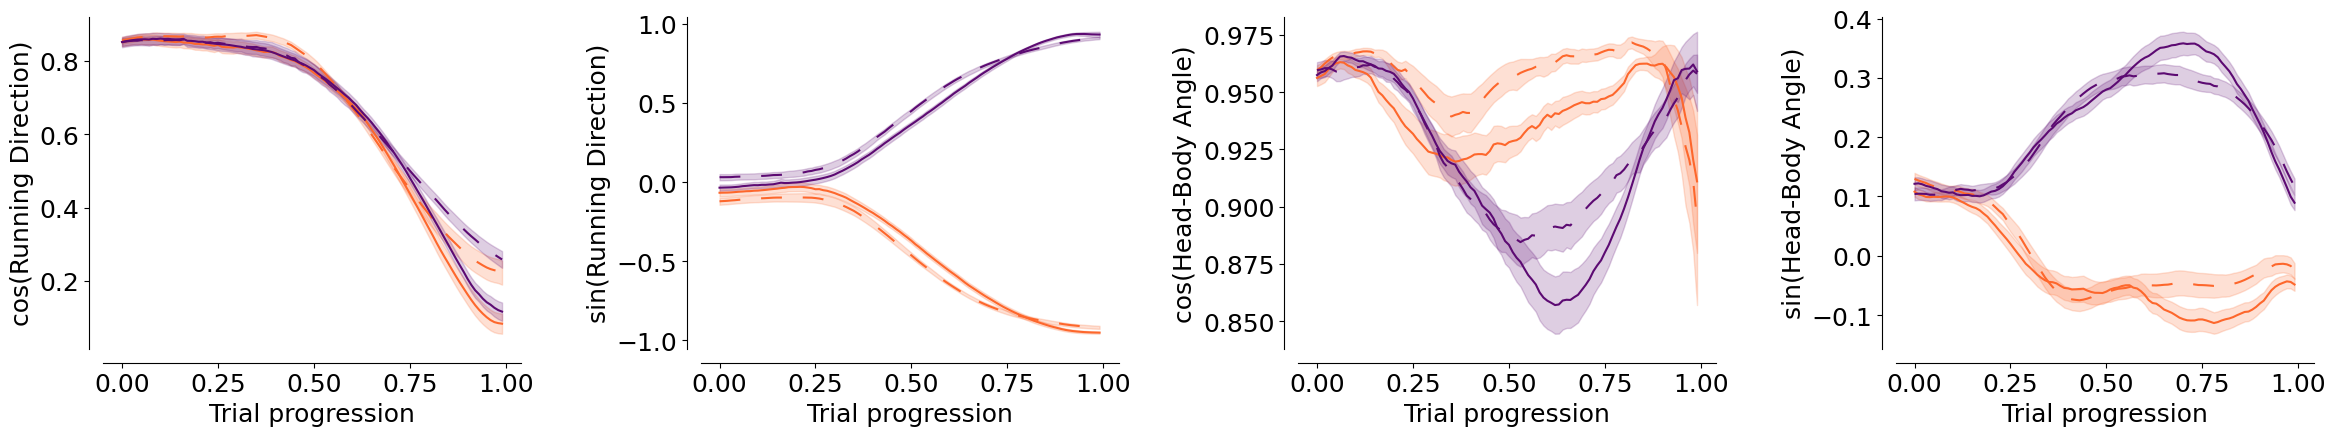

In [11]:
mean_mouse = interpolated_df.groupby(
    ["dataset", "aperture", "trial_left_choice", "trial_length"], as_index=False
).mean(numeric_only=True)

fig, ax = plt.subplots(1, 4, figsize=(24, 5))
ax = ax.flatten()

dash_styles = {
    mean_mouse.aperture.unique()[0]: "",         # Solid
    mean_mouse.aperture.unique()[1]: (10, 10)      # Dashed
}

for (i, label), label_str in zip(enumerate(
    ["heading_dir_cos", "heading_dir_sin", "head_angle_cos", "head_angle_sin"]
), ["cos(Running Direction)", "sin(Running Direction)", "cos(Head-Body Angle)", "sin(Head-Body Angle)"]):
    sns.lineplot(
        data=mean_mouse,
        x="trial_length",
        y=label,
        palette=plotting.colors_choice[::-1]
        if len(mean_mouse.aperture.unique()) == 2
        else "viridis",
        hue="trial_left_choice"
        if len(mean_mouse.aperture.unique()) == 2
        else "aperture",
        style=(
            "aperture"
            if len(mean_mouse.aperture.unique()) == 2
            else "trial_left_choice"
        ),
        errorbar="se",
        ax=ax[i],
        dashes=dash_styles,
    )
    ax[i].set_ylabel(label_str)
    ax[i].set_xlabel("Trial progression")
    sns.despine(ax=ax[i], offset=10)

    ax[i].legend().remove()
    
plt.tight_layout(pad=3)
plt.savefig(save_fig_path + "figure3_heading_dir_head_angle_cos_sin.svg", bbox_inches="tight", transparent=True)
plt.savefig(save_fig_path + "figure3_heading_dir_head_angle_cos_sin.png", bbox_inches="tight", transparent=True, dpi=300)

In [12]:
model_labels = regression.model_labels 

In [13]:
interpolated_df["aperture"] = interpolated_df["aperture"].astype(float)

df_model, coef = regression.predict_decision(
    df=interpolated_df, label=model_labels, per_mouse=True
)

In [14]:
coef.shape

(43, 12)

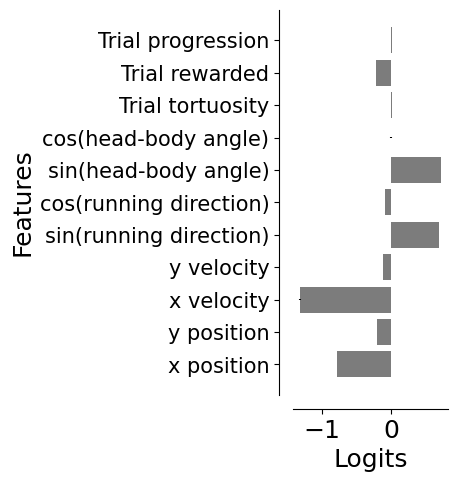

In [15]:
# Logits of the regression
import scipy.stats
fig, ax = plt.subplots(1, 1, figsize=(2, 5))
ax.barh(
    regression.model_labels,
    np.mean(coef[:, 1:], axis=0),
    yerr=scipy.stats.sem(coef[:, 1:], axis=0),
    color="#7C7C7C",
)
sns.despine(offset=10, ax=ax)

ax.set_yticks(np.arange(len(regression.model_labels)))
ax.set_yticklabels(regression.clean_model_labels, rotation=0, ha="right", fontsize=15)
ax.set_xlabel("Logits")
ax.set_ylabel("Features")

plt.savefig(save_fig_path + "figure3_dual_occluder_model_logits.svg", transparent=False)

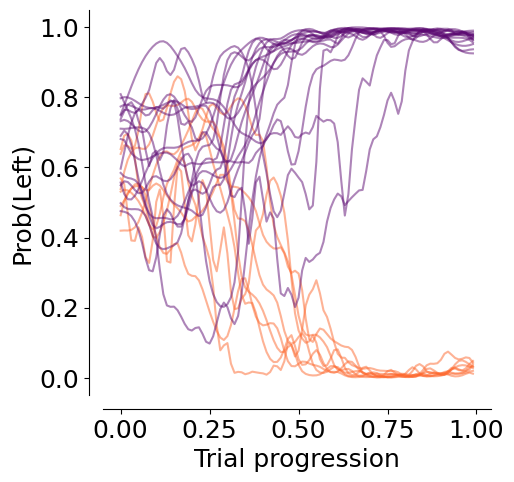

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

group = df_model[(df_model.dataset == "Kiwi_2024-08-14_1")]

trials = [
    94,
    15,
    66,
    170,
    224,
    195,
    56,
    203,
    88,
    239,
    113,
    91,
    186,
    248,
    109,
    164,
    188,
    60,
    229,
    182,
    156,
    197,
    52,
    45,
]  # 110, 156, 190,  22, 210,  24,  51,  78,
# 239,  97,  24, 176, 168, 184, 123, 156]

group = group[group.trial.isin(np.array(trials))]
sns.lineplot(
    data=group,
    x="trial_length",
    y="proba_left",
    hue="trial_left_choice",
    errorbar=None,
    estimator=None,
    units="trial",
    palette=plotting.colors_choice[::-1],
    sort=False,
    alpha=0.5,
    ax=ax,
)
ax.set_ylabel("Prob(Left)")
ax.set_xlabel("Trial progression")
ax.legend([], [], frameon=False)
sns.despine(offset=10)

plt.savefig(
    save_fig_path + "figure3_dual_occluder_dynamic_decision_variable.svg",
    transparent=True,
)

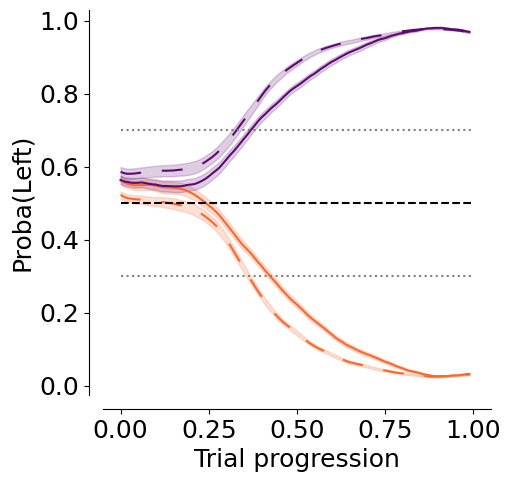

In [17]:
df_model_mean =  df_model.groupby(["dataset", "aperture", "trial_left_choice", "trial_length"], as_index=False).mean()
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

dash_styles = {
    mean_mouse.aperture.unique()[0]: "",         # Solid
    mean_mouse.aperture.unique()[1]: (10, 10)      # Dashed
}

sns.lineplot(
    data=df_model_mean,
    x="trial_length",
    y="proba_left",
    hue="trial_left_choice",
    style="aperture",
    palette=plotting.colors_choice[::-1],
    sort=False,
    alpha=1,
    ax=ax,
    errorbar="se",
    dashes=dash_styles
)
ax.set_ylabel("Proba(Left)")
ax.set_xlabel("Trial progression")

ax.hlines(0.5, xmin=0, xmax=1, colors="black", linestyles="dashed")
ax.hlines(0.7, xmin=0, xmax=1, colors="gray", linestyles="dotted")
ax.hlines(0.3, xmin=0, xmax=1, colors="gray", linestyles="dotted")
ax.legend([], [], frameon=False)
sns.despine(offset=10)

plt.savefig(
    save_fig_path + "figure3_dual_occluder_dynamic_decision_variable_avg.png",
    transparent=True,
    dpi=300,
)

plt.savefig(
    save_fig_path + "figure3_dual_occluder_dynamic_decision_variable_avg.svg",
    transparent=True,
)

In [18]:
df_model_mean =  df_model.groupby(["dataset", "aperture", "trial_length"], as_index=False).mean()

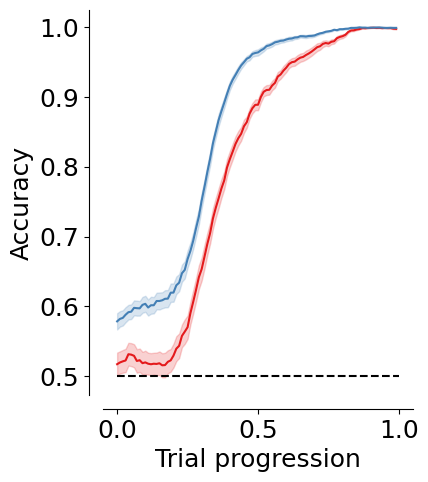

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(4, 5))
sns.lineplot(
    data=df_model_mean,
    x="trial_length",
    y="accuracy",
    hue="aperture",
    palette=plotting.colors_aperture,
    sort=False,
    alpha=1,
    ax=ax,
    errorbar="se"
)
ax.hlines(0.5, 0, 1, color="black", linestyle="--")

ax.set_ylabel("Accuracy")
ax.set_xlabel("Trial progression")
ax.legend([], [], frameon=False)
sns.despine(offset=10)

plt.savefig(
    save_fig_path + "figure3_dual_occluder_model_accuracy.svg", transparent=True
)

In [20]:
df_model["trial_length_bin"] = pd.cut(
    df_model["trial_length"], bins=50
)  # Adjust bins as needed
df_anova = df_model.groupby(
    ["dataset", "aperture", "trial_length_bin"], as_index=False
)["accuracy"].mean()

print(
    AnovaRM(
        data=df_anova,
        depvar="accuracy",
        subject="dataset",
        within=["aperture", "trial_length_bin"],
    ).fit()
)

                           Anova
                           F Value   Num DF   Den DF  Pr > F
------------------------------------------------------------
aperture                    51.5508  1.0000   42.0000 0.0000
trial_length_bin          1029.1316 49.0000 2058.0000 0.0000
aperture:trial_length_bin   15.0817 49.0000 2058.0000 0.0000



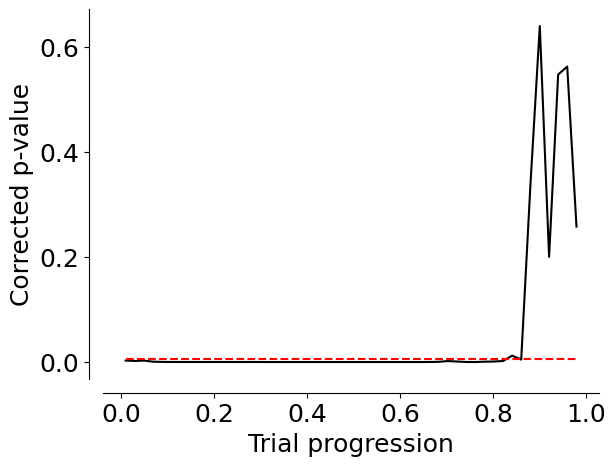

In [21]:
p_values = []
for i in df_anova.trial_length_bin.unique():
    section = df_anova[df_anova.trial_length_bin == i]
    t = ttest_ind(
        section[section.aperture == section.aperture.unique()[0]].accuracy,
        section[section.aperture == section.aperture.unique()[1]].accuracy,
    )
    p_values.append(pd.DataFrame({"segment": i, "p_value": t.pvalue}, index=[0]))

p_value_df = pd.concat(p_values)
p_value_df["p_value_corr"] = stats.false_discovery_control(p_value_df.p_value)

# Convert interval bins to numeric midpoints
p_value_df["segment"] = p_value_df["segment"].apply(lambda x: x.mid)

plt.plot(p_value_df.segment, p_value_df.p_value_corr, c="k")

plt.hlines(
    0.005,
    xmin=p_value_df.segment.min(),
    xmax=p_value_df.segment.max(),
    color="red",
    linestyle="dashed",
)

plt.xlabel("Trial progression")
plt.ylabel("Corrected p-value")

sns.despine(offset=10)
plt.savefig(
    save_fig_path + "figure3_dual_occluder_model_accuracy_pvalue.svg", transparent=True
)

## Get the decision points

In [22]:
decision_points = regression.find_decision_point(df_model, 
                                                 threshold_uncertainty=0.3)

Decision Time: 0.33


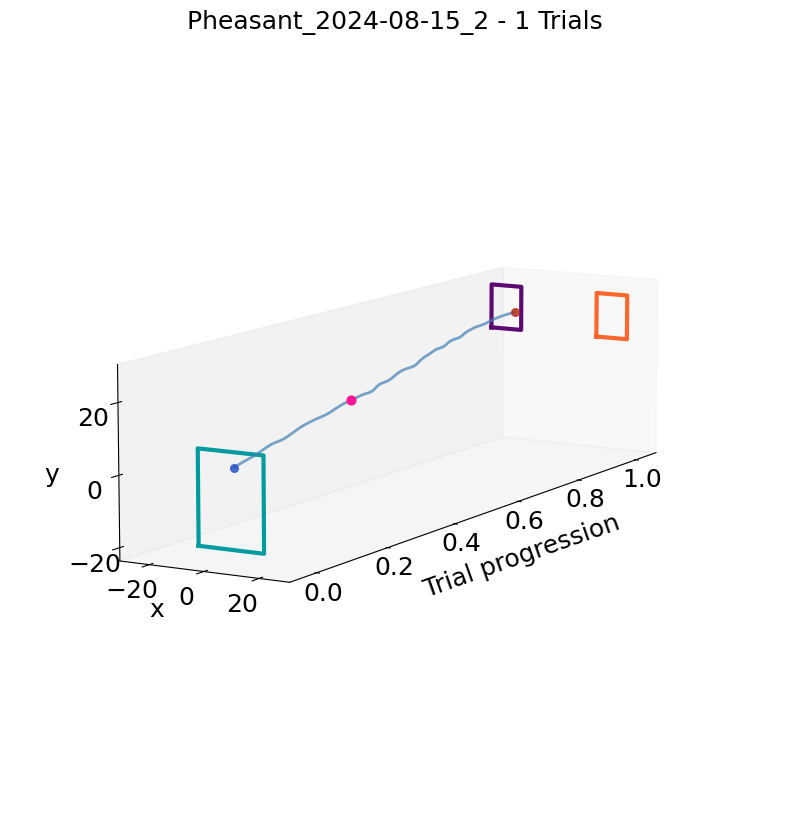

In [23]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

ax = plotting.plot_session_3d(
    df=interpolated_df[interpolated_df.dataset == "Pheasant_2024-08-15_2"],
    box_df=box_df,
    trial_ids=[69],
    ax=ax,
    color_by_aperture=True,
    color_by_choice=False,
    decision_points=decision_points[decision_points.dataset == "Pheasant_2024-08-15_2"]
)

plt.savefig(save_fig_path + "figure3_dual_occluder_3d_trajectory_wide.svg", bbox_inches="tight", transparent=True)

Decision Time: 0.42


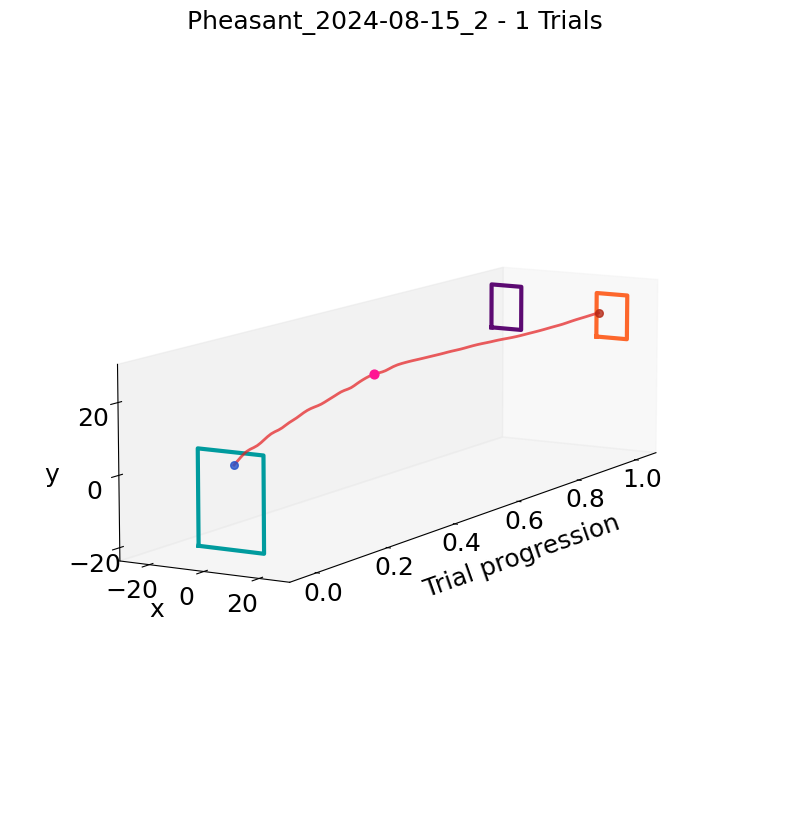

In [24]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

ax = plotting.plot_session_3d(
    df=interpolated_df[interpolated_df.dataset == "Pheasant_2024-08-15_2"],
    box_df=box_df,
    trial_ids=[125],
    ax=ax,
    color_by_aperture=True,
    color_by_choice=False,
    decision_points=decision_points[decision_points.dataset == "Pheasant_2024-08-15_2"]
)

plt.savefig(save_fig_path + "figure3_dual_occluder_3d_trajectory_narrow.svg", bbox_inches="tight", transparent=True)

In [25]:
with open("notebooks/Paper_figures/info_matrix_52x52x31_124.npy", "rb") as file:
    info_matrix_narrow = np.rot90(np.load(file), k=1)
with open("notebooks/Paper_figures/info_matrix_52x52x31_346.npy", "rb") as file:
    info_matrix_wide = np.rot90(np.load(file), k=1)

info_matrices = [info_matrix_narrow, info_matrix_wide]

# normalize info matrices to max 1
info_matrices = [im / im.max() for im in info_matrices]

/tmp/ipykernel_2686263/1849721202.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  base_cmap = cm.get_cmap("PuOr")


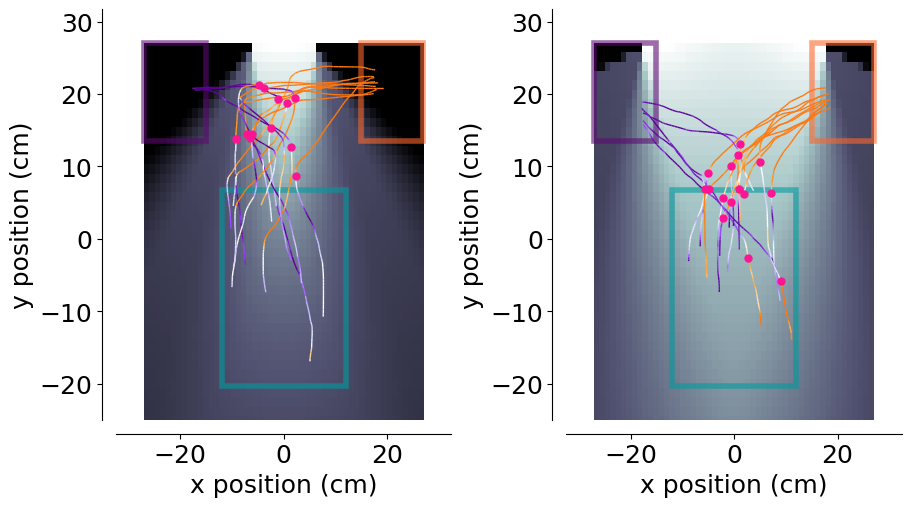

In [26]:
import matplotlib.colors as mcolors
import matplotlib.cm as cm

fig, ax = plt.subplots(
    1, len(df_model.aperture.unique()), figsize=(9, 5), constrained_layout=True
)

decision_color = "deeppink"
session_to_plot = "Pheasant_2024-08-15_2"
box_df = base_analysis.BoxDataFrame().get_data(key={"dataset": "Pheasant_2024-08-15_2"})

trials = [44, 45, 19, 62, 61, 45, 85, 41, 43, 41, 50, 75, 24, 69, 84, 74, 10] + [
    63,
    30,
    78,
    47,
    33,
    5,
    17,
    9,
    47,
    30,
    99,
    11,
    12,
    15,
]

# Start from PuOr
base_cmap = cm.get_cmap("PuOr")

# Make a brighter version by rescaling luminance
def brighten(cmap, factor=2):
    colors = cmap(np.linspace(0, 1, 256))
    rgb = mcolors.rgb_to_hsv(colors[:, :3])
    rgb[:, 2] = rgb[:, 2] * factor  # brighten value channel
    rgb[:, 2] = np.clip(rgb[:, 2], 0, 1)
    colors[:, :3] = mcolors.hsv_to_rgb(rgb)
    return mcolors.ListedColormap(colors)

bright_puor = brighten(base_cmap)

for i, aperture in enumerate(df_model.aperture.unique()[::-1]):
    regression.plot_decision_points_on_trajectory(
        df_model[
            (df_model.dataset == session_to_plot) & (df_model.aperture == aperture)
        ],
        box_df,
        decision_point=decision_points[
            (decision_points.dataset == session_to_plot)
            & (decision_points.aperture == aperture)
        ],
        color=decision_color,
        trials=trials,
        ax=ax[i],
        cmap=bright_puor,
    )
    
    xlim = ax[i].get_xlim()
    ylim = ax[i].get_ylim()

    im = ax[i].imshow(info_matrices[i], 
                 cmap="bone", 
                 extent=[-27, 27, -27, 27],
                 zorder=-10)
    
    ax[i].set_xlim(xlim)
    ax[i].set_ylim(ylim)
    ax[i].set_aspect(1.4)
    ax[i].set_xlabel("x position (cm)")
    ax[i].set_ylabel("y position (cm)")
    sns.despine(offset=10, ax=ax[i])

#fig.colorbar(im, ax=ax, orientation="vertical", fraction=0.03, pad=0.04, label="Information content rate")
plt.savefig(
    save_fig_path + "figure3_dual_occluder_decision_points_trajectories_bright.svg",
    transparent=True,
)

## Information contained at decision point per condition

In [27]:
def get_info_at_position(info_matrix, position):
    # Assuming info_matrix is a 2D numpy array and position is a tuple (x, y)
    x, y = position
    # Convert position to matrix indices
    x_idx = int(x + 27)
    y_idx = int(y + 27)
    
    # but the matrix is 52x42 so the positions need to be scaled down
    x_idx_norm = int(x_idx * (51 / 54))
    y_idx_norm = int(y_idx * (41 / 54))
    
    y_idx_norm = info_matrix.shape[0] - 1 - y_idx_norm
    return info_matrix[y_idx_norm, x_idx_norm]  # Note: y comes first in matrix indexing

In [28]:
# for each trial, get the initial position
initial_positions = interpolated_df.groupby(
    ["mouse_name", "dataset", "aperture", "trial"], as_index=False
).first()[["mouse_name", "dataset", "aperture", "trial", "x", "y"]]

# Get info at initial position
initial_positions["info_gain"] = initial_positions.apply(
    lambda row: get_info_at_position(
        info_matrices[0] if row.aperture == 4.3 else info_matrices[1],
        (row.x, row.y),
    ),
    axis=1,
)

In [29]:
decision_points["mouse_name"] = decision_points.dataset.str.split("_").str [0]

# Decision point information available
info_at_decision_per_session = decision_points.groupby(["mouse_name", "dataset", "aperture"], as_index=False).apply(
    lambda x: get_info_at_position(
        info_matrices[0] if x.aperture.values[0] == 4.3 else info_matrices[1],
        (x.x.mean(), x.y.mean()),
    )
)
info_at_decision_per_session = info_at_decision_per_session.rename(columns={None: "info_gain"})
info_at_decision_per_session["count"] = info_at_decision_per_session["info_gain"]
info_at_decision_per_session = pd.DataFrame(info_at_decision_per_session.reset_index())
info_at_decision_per_session.aperture = info_at_decision_per_session.aperture.round(2).astype(str)

# Initial position information available
initial_positions = initial_positions.groupby(["mouse_name", "dataset", "aperture"], as_index=False)["info_gain"].mean()
initial_positions["count"] = initial_positions["info_gain"]
initial_positions = pd.DataFrame(initial_positions.reset_index())
initial_positions.aperture = initial_positions.aperture.astype(float).round(2).astype(str)

# Difference in information available
information_difference = info_at_decision_per_session.copy()
information_difference["info_gain"] = information_difference["info_gain"] - initial_positions["info_gain"]
information_difference["count"] = information_difference["info_gain"]
information_difference = pd.DataFrame(information_difference.reset_index())
information_difference.aperture = information_difference.aperture.astype(float).round(2).astype(str)

2026-01-20 16:31:46,580::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-20 16:31:46,580::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-20 16:31:46,594::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-20 16:31:46,594::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-20 16:31:46,720::INFO::category.py::Using categorical un

Information at Initiation
mean: 0.46107538928717773 +/- 0.002586592804136966
12.0-4.3: TtestResult(statistic=123.34056502985698, pvalue=2.113213797110614e-55, df=42)
mean: 0.6788369968352709 +/- 0.0022108611985671815
Information at Decision
mean: 0.6856721391292366 +/- 0.008626026993013142
12.0-4.3: TtestResult(statistic=10.297303102226392, pvalue=4.644889800170309e-13, df=42)
mean: 0.7643672475739298 +/- 0.003059032213198168
Information Difference
mean: 0.22459674984205888 +/- 0.008758099887320016
12.0-4.3: TtestResult(statistic=-16.662319394034693, pvalue=4.0494321988191544e-20, df=42)
mean: 0.08553025073865907 +/- 0.0020843413453377263


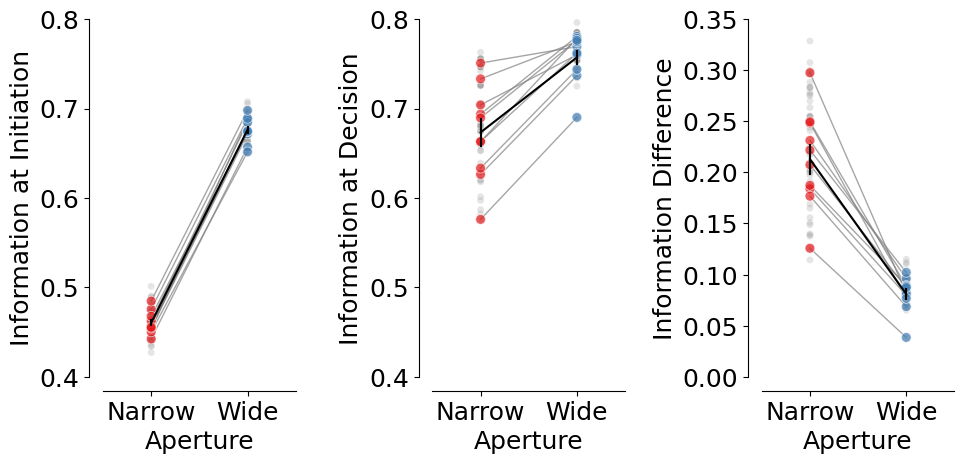

In [30]:
fig, ax = plt.subplots(1, 3, figsize=(10, 5))


plotting._plot_bar_counts(
    counts=initial_positions,
    label_x="aperture",
    alpha=0.2,
    ax=ax[0],
    per_mouse=True,
    cmap=plotting.colors_aperture[0:2],
)
ax[0].invert_xaxis()
ax[0].set_ylabel("Information at Initiation")
ax[0].set_xlim(-0.5, 1.5)
ax[0].set_xticks([0, 1], ["Narrow", "Wide"])
ax[0].set_xlabel("Aperture")
ax[0].legend([], [], frameon=False)
sns.despine(offset=10, ax=ax[0])

plotting._plot_bar_counts(
    counts=info_at_decision_per_session,
    label_x="aperture",
    alpha=0.2,
    ax=ax[1],
    per_mouse=True,
    cmap=plotting.colors_aperture[0:2],
)
ax[1].invert_xaxis()
ax[1].set_ylabel("Information at Decision")
ax[1].set_xlim(-0.5, 1.5)
ax[1].set_xticks([0, 1], ["Narrow", "Wide"])
ax[1].set_xlabel("Aperture")
ax[1].legend([], [], frameon=False)
sns.despine(offset=10, ax=ax[1])

plotting._plot_bar_counts(
    counts=information_difference,
    label_x="aperture",
    alpha=0.2,
    ax=ax[2],
    per_mouse=True,
    cmap=plotting.colors_aperture[0:2],
)
ax[2].invert_xaxis()
ax[2].set_ylabel("Information Difference")
ax[2].set_xlim(-0.5, 1.5)
ax[2].set_xticks([0, 1], ["Narrow", "Wide"])
ax[2].set_xlabel("Aperture")
ax[2].legend([], [], frameon=False)
sns.despine(offset=10, ax=ax[2])

ax[0].set_ylim(0.4, 0.8)
ax[1].set_ylim(0.4, 0.8)
ax[2].set_ylim(0, 0.35)

plt.tight_layout(pad=2)
plt.savefig(
    save_fig_path + "figure3_dual_occluder_information_quantification.svg",
    transparent=True,
)


for info, label in zip([initial_positions, info_at_decision_per_session, information_difference],
                       ["Information at Initiation", "Information at Decision", "Information Difference"]):
    print(label)
    for i in info.aperture.unique():
        for j in info.aperture.unique():
            if i < j:
                stat = stats.ttest_rel(
                    info[info["aperture"] == i]["count"],
                    info[info["aperture"] == j]["count"],
                )
                print(f"{i}-{j}: {stat}")
        print(f"mean: {info[info['aperture'] == i]['count'].mean()} +/- {stats.sem(info[info['aperture'] == i]['count'])}")


In [31]:
# Get mean + sem for all 
for info, label in zip([initial_positions, info_at_decision_per_session, information_difference],
                       ["Information at Initiation", "Information at Decision", "Information Difference"]):
    print(label)
    # round to 2 decimals
    print(info.groupby("aperture")["count"].mean().round(3))
    print(info.groupby("aperture")["count"].sem().round(3))

Information at Initiation
aperture
12.0    0.679
4.3     0.461
Name: count, dtype: float64
aperture
12.0    0.002
4.3     0.003
Name: count, dtype: float64
Information at Decision
aperture
12.0    0.764
4.3     0.686
Name: count, dtype: float64
aperture
12.0    0.003
4.3     0.009
Name: count, dtype: float64
Information Difference
aperture
12.0    0.086
4.3     0.225
Name: count, dtype: float64
aperture
12.0    0.002
4.3     0.009
Name: count, dtype: float64


## Distance to screen of the decision points per condition

2026-01-20 16:31:48,507::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-20 16:31:48,507::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-20 16:31:48,518::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-20 16:31:48,518::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-20 16:31:48,639::INFO::category.py::Using categorical un

mean: 12.04011070556461 +/- 0.46545547951598176
12.0-4.3: TtestResult(statistic=-6.10829976443622, pvalue=2.774402864524896e-07, df=42)
 mean difference:  3.9081198879131147
mean: 8.131990817651495 +/- 0.388674664871373


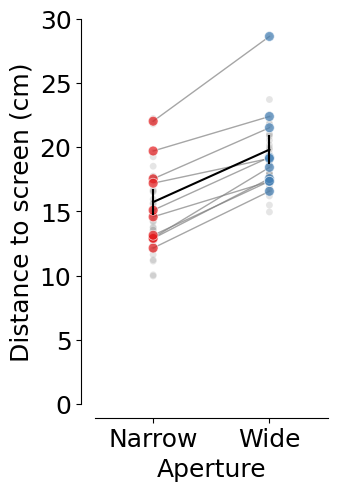

In [32]:
fig, ax = plt.subplots(1, 1, figsize=(3, 5))
stats = plotting.pairplot_average_decision_point(
    decision_points,
    label_parameter="y",
    ax=ax,
    cmap=plotting.colors_aperture,
    per_mouse=True,
)
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(0, 30)
ax.set_xlabel("Aperture")
ax.set_xticks([0, 1], ["Narrow", "Wide"])
ax.set_ylabel("Distance to screen (cm)")
sns.despine(offset=10)
plt.legend([], [], frameon=False)

plt.savefig(
    save_fig_path + "figure3_dual_occluder_decision_points_distance.svg",
    transparent=True,
)

In [33]:
decision_points["lab_id"] = 0
for dataset_name in mouse_list:
    # Fetch lab_id for each dataset
    decision_points.loc[decision_points.dataset==dataset_name, "lab_id"] = ((vr4mice.Collab() & f'dataset = "{dataset_name}"') * vr4mice.Labs()).fetch("lab")[0]

2026-01-20 16:31:53,118::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-20 16:31:53,118::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-20 16:31:53,139::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-20 16:31:53,139::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-20 16:31:53,210::INFO::category.py::Using categorical un

mean: 12.04011070556461 +/- 0.4654554795159817
12.0-4.3: TtestResult(statistic=-12.260133388273452, pvalue=1.8309406469185003e-15, df=42)
 mean difference:  3.9081198879131147
mean: 8.131990817651495 +/- 0.388674664871373


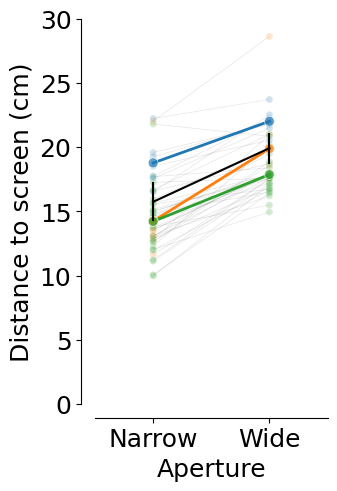

In [34]:
fig, ax = plt.subplots(1, 1, figsize=(3, 5))
stats_pair = plotting.pairplot_average_decision_point(
    decision_points,
    label_parameter="y",
    ax=ax,
    cmap=plotting.colors_aperture,
    per_lab=True,
)
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(0, 30)
ax.set_xlabel("Aperture")
ax.set_xticks([0, 1], ["Narrow", "Wide"])
ax.set_ylabel("Distance to screen (cm)")
sns.despine(offset=10)
plt.legend([], [], frameon=False)

plt.savefig(
    save_fig_path + "figure3_dual_occluder_decision_points_distance_per_lab.svg",
    transparent=True,
)

In [35]:
decision_points_stats = decision_points.groupby(["dataset", "aperture"], as_index=False)[
    "y"
].mean()
anova_rm = AnovaRM(decision_points_stats, depvar="y", subject="dataset", within=["aperture"])

anova_results = anova_rm.fit()
anova_table = anova_results.summary()
print(anova_table)

                 Anova
         F Value  Num DF  Den DF Pr > F
---------------------------------------
aperture 150.3109 1.0000 42.0000 0.0000



In [36]:
decision_points_stats.groupby("aperture").y.mean(), decision_points_stats.groupby("aperture").y.sem()

(aperture
 4.3     12.040111
 12.0     8.131991
 Name: y, dtype: float64,
 aperture
 4.3     0.465455
 12.0    0.388675
 Name: y, dtype: float64)

# Relate decision point position to reward rate

In [37]:
test = decision_points.groupby(["dataset", "aperture"], as_index=False).mean()

In [38]:
# get first and last quartile of decision points, per dataset
first_quartiles = test[test.aperture==4.3]['y'].quantile(0.2)
last_quartiles = test[test.aperture==4.3]['y'].quantile(0.8)

# get the dfs before q1 and after q3
before_q1 = test[(test.aperture==4.3) & (test['y'] < first_quartiles)] #furthest from screen
after_q3 = test[(test.aperture==4.3) & (test['y'] > last_quartiles)] #closest to screen

# add column for mouse name
before_q1["mouse_name"] = before_q1.dataset.str.split("_").str [0]
after_q3["mouse_name"] = after_q3.dataset.str.split("_").str [0]

/tmp/ipykernel_2686263/3073440858.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  before_q1["mouse_name"] = before_q1.dataset.str.split("_").str [0]
/tmp/ipykernel_2686263/3073440858.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after_q3["mouse_name"] = after_q3.dataset.str.split("_").str [0]


In [39]:
before_q1.mouse_name.unique(), after_q3.mouse_name.unique()

(array(['31726', '31728', 'J731', 'Pheasant'], dtype=object),
 array(['J729', 'Jacana', 'Lemming', 'Nightingale', 'Oribi'], dtype=object))

In [40]:
before_q1.dataset.nunique(), after_q3.dataset.nunique()

(9, 9)

In [41]:
# get reward rate
trial_df = (TrialMetrics() * vr4mice.Groups() * vr4mice.Labels() * (vr4mice.Dataset() & 'session_label = "ar_discrim_occluders"')).fetch(as_dict=True)
trial_df =  pd.concat([pd.DataFrame(x) for x in trial_df])

# Exclude sessions that were not in the list
trial_df, reward_table = utils.apply_inclusion_criteria(trial_df, 
                                                        task_type="dual_occluder",
                                                        return_excluded=False)

# Create list of included datasets
mouse_list = trial_df.dataset.unique()
trial_df["mouse_name"] = trial_df.dataset.str.split("_").str [0]

trial_df["lab_id"] = 0
for dataset_name in mouse_list:
    # Fetch lab_id for each dataset
    trial_df.loc[trial_df.dataset==dataset_name, "lab_id"] = ((vr4mice.Collab() & f'dataset = "{dataset_name}"') * vr4mice.Labs()).fetch("lab")[0]

2026-01-20 16:31:58,795::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-20 16:31:58,795::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-20 16:31:58,806::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-20 16:31:58,806::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-20 16:31:58,871::INFO::category.py::Using categorical un

mean: 0.7034696062318463, sem: 0.01661437129648618
12.0-4.3: TtestResult(statistic=6.020836716544765, pvalue=6.021298430409706e-05, df=12)
mean: 0.8670625356096114, sem: 0.015597592114807973


2026-01-20 16:31:59,158::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-20 16:31:59,158::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-20 16:31:59,170::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-20 16:31:59,170::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-20 16:31:59,173::INFO::category.py::Using categorical un

mean: 0.7951417364353957, sem: 0.019065061731189922
12.0-4.3: TtestResult(statistic=3.901005225271365, pvalue=0.0006764185883433609, df=24)
mean: 0.8837975710050653, sem: 0.010775665660272405


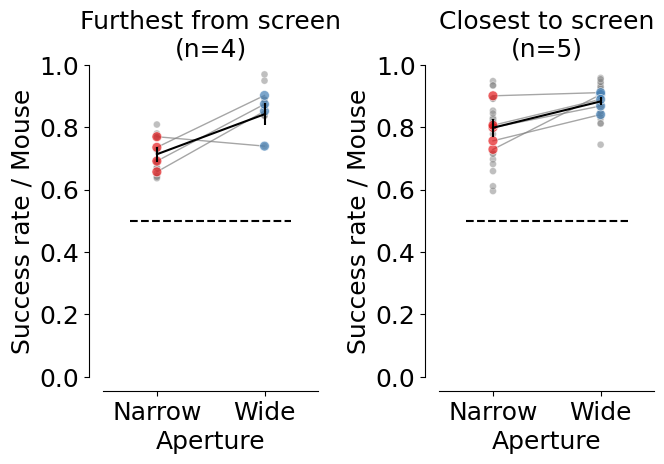

In [42]:
# plot the lower and upper quartile reward rate for only the sessions in the quartiles
fig, ax = plt.subplots(1, 2, figsize=(7, 5))

counts = plotting.plot_rate(
    df=trial_df[trial_df.mouse_name.isin(before_q1.mouse_name.unique().tolist())],
    label_x="trial_rewarded",
    per_aperture=True,
    ax=ax[0],
    cmap=plotting.colors_aperture[0:2],
    per_mouse=True,
)

ax[0].hlines(
    0.5,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="black",
)
ax[0].set_ylim(0, 1.0)
ax[0].set_xlim(-0.5, 1.5)
ax[0].set_ylabel("Success rate / Mouse")
ax[0].set_xlabel("Aperture")
ax[0].set_xticks([0, 1], ["Narrow", "Wide"])
sns.despine(offset=10, ax=ax[0])
ax[0].legend([], [], frameon=False)
ax[0].set_title(f"Furthest from screen\n(n={counts.mouse_name.nunique()})")

counts2 = plotting.plot_rate(
    df=trial_df[trial_df.mouse_name.isin(after_q3.mouse_name.unique().tolist())],
    label_x="trial_rewarded",
    per_aperture=True,
    ax=ax[1],
    cmap=plotting.colors_aperture[0:2],
    per_mouse=True,
)

ax[1].hlines(
    0.5,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="black",
)
ax[1].set_ylim(0, 1.0)
ax[1].set_xlim(-0.5, 1.5)
ax[1].set_ylabel("Success rate / Mouse")
ax[1].set_xlabel("Aperture")
ax[1].set_xticks([0, 1], ["Narrow", "Wide"])
sns.despine(offset=10, ax=ax[1])
ax[1].legend([], [], frameon=False)
ax[1].set_title(f"Closest to screen\n(n={counts2.mouse_name.nunique()})")
plt.savefig(save_fig_path + "figure3_trial_reward_groups.svg", transparent=True)

plt.tight_layout(pad=2)

In [43]:
# stats difference between groups
stats_res = ttest_ind(
    counts[counts.aperture=="4.3"]["count"],
    counts2[counts2.aperture=="4.3"]["count"]
)
print("narrow", stats_res)

stats_res = ttest_ind(
    counts[counts.aperture=="12.0"]["count"],
    counts2[counts2.aperture=="12.0"]["count"]
)
print("wide", stats_res)

narrow TtestResult(statistic=-3.1477142046073885, pvalue=0.0032991503807354478, df=36.0)
wide TtestResult(statistic=-0.8951141071836514, pvalue=0.37667219573341515, df=36.0)


### Decision point distance to screen vs. reward rate
Including sessions with the narrow-wide difference in reward rate > 0.25

In [45]:
trial_df = (TrialMetrics() * vr4mice.Groups() * vr4mice.Labels() * (vr4mice.Dataset() & 'session_label = "ar_discrim_occluders"')).fetch(as_dict=True)
trial_df =  pd.concat([pd.DataFrame(x) for x in trial_df])
# Exclude sessions that were not in the list
trial_df, reward_table = utils.apply_inclusion_criteria(trial_df, 
                                                        task_type="dual_occluder",
                                                        return_excluded=False,
                                                        consider_reward_drop=False)
# Create list of included datasets
mouse_list = trial_df.dataset.unique()
trial_df["mouse_name"] = trial_df.dataset.str.split("_").str [0]

In [46]:
# This takes a while to fetch because we need to fetch data for all trials (4 min 20 secs) 
dataset_list = []
for d in mouse_list:
    print(d)
    try:
        if len(InterpolatedTrials() & f'dataset = "{d}"') > 0:
            dataset_list.append(pd.DataFrame((InterpolatedTrials() & f'dataset = "{d}"').fetch(as_dict=True)[0]))
        else:
            print("dataset missing")
    except Exception as err:
        print(err, " dataset missing")
interpolated_df = pd.concat(dataset_list)
interpolated_df["mouse_name"] = interpolated_df.dataset.str.split("_").str [0]

Pheasant_2024-08-21_1
Pheasant_2024-08-20_1


Pheasant_2024-08-19_1
Pheasant_2024-08-16_1
Pheasant_2024-08-15_2
Oribi_2024-08-22_1
Oribi_2024-08-21_1
Oribi_2024-08-20_1
Oribi_2024-08-19_1
Oribi_2024-08-16_1
Nightingale_2024-08-14_1
Nightingale_2024-08-13_1
Nightingale_2024-08-12_1
Nightingale_2024-08-11_1
Nightingale_2024-08-10_1
Lemming_2024-08-13_1
Lemming_2024-08-12_1
Lemming_2024-08-11_1
Lemming_2024-08-10_1
Kiwi_2024-08-14_1
Kiwi_2024-08-13_1
Kiwi_2024-08-12_2
Kiwi_2024-08-11_4
Kiwi_2024-08-10_2
Jacana_2024-08-19_1
Jacana_2024-08-16_1
Jacana_2024-08-15_1
Jacana_2024-08-14_1
Jacana_2024-08-13_1
J731_2024-12-09_1
J731_2024-12-05_1
J729_2024-12-10_1
J729_2024-12-04_1
J729_2024-12-03_1
J729_2024-12-02_1
J729_2024-12-01_1
J729_2024-11-30_1
31728_2025-03-21_1
31728_2025-03-20_1
31728_2025-03-07_1
31728_2025-03-06_1
31728_2025-03-05_1
31726_2025-03-21_1
31726_2025-03-20_1
31726_2025-03-19_1
31726_2025-03-18_1


In [52]:
interpolated_df.dataset.nunique(), interpolated_df.mouse_name.nunique()

(46, 10)

In [47]:
model_labels = regression.model_labels 

In [48]:
interpolated_df["aperture"] = interpolated_df["aperture"].astype(float)

df_model, coef = regression.predict_decision(
    df=interpolated_df, label=model_labels, per_mouse=True
)

In [49]:
decision_points = regression.find_decision_point(df_model, 
                                                 threshold_uncertainty=0.3)

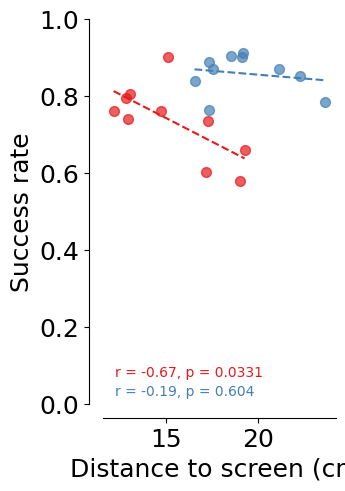

In [53]:
fig, ax = plt.subplots(1, 1, figsize=(3, 5))

for aperture, color, ypos in zip(decision_points.sort_values("aperture").aperture.unique(), 
                                     plotting.colors_aperture,
                                     [0.10, 0.05]):
    x = abs(decision_points[decision_points.aperture==aperture].groupby(
        "mouse_name")["y"].mean().values - 27)
    y = trial_df[(trial_df.aperture==aperture)].groupby(
        "mouse_name")["trial_rewarded"].mean().values


    # scatter
    ax.scatter(
        x, y,
        color=color,
        alpha=0.7,
        s=50
    )

    # regression line
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = slope * x_fit + intercept
    ax.plot(x_fit, y_fit, color=color, linestyle="--")

    # annotate correlation
    ax.text(
        0.05, ypos,
        f"r = {r_value:.2f}, p = {p_value:.3g}",
        transform=ax.transAxes,
        va="top", ha="left",
        color=color
    )

    ax.set_xlabel("Distance to screen (cm)")
    ax.set_ylabel("Success rate")
    ax.set_ylim(0, 1.0)
    sns.despine(offset=10, ax=ax)

plt.savefig(save_fig_path + "figure3_dual_occluder_decision_point_vs_performance.svg", transparent=True)